In [81]:
import pandas as pd
import numpy as np

In [82]:
df = pd.DataFrame({
    "products": [
        "iPhone 15",
        "Samsung TV",
        "Nike Shoes",
        "Dell Laptop",
        "Boat Headphones",
        "Apple Watch",
        "HP Printer",
        "Sony Camera",
        "Adidas T-Shirt",
        "LG Refrigerator",
        "OnePlus Phone",
        "Puma Sneakers",
        "Lenovo Tablet",
        "JBL Speaker",
        "Canon Printer",
        "Asus Monitor",
        "Realme Buds",
        "Wooden Chair",
        "Gaming Mouse",
        "Mi Power Bank"
    ],

    "text_reviews": [
        "Excellent camera quality and smooth performance.",
        "Picture quality is amazing but sound could be better.",
        "Very comfortable and stylish for daily use.",
        "Fast performance and good battery backup.",
        "Sound quality is decent for the price.",
        "Fitness tracking is accurate and battery lasts long.",
        "Printing speed is good and setup was easy.",
        "Image quality is sharp and professional.",
        "Fabric quality is soft and comfortable.",
        "Cooling performance is excellent and energy efficient.",
        "Phone is fast but heats slightly during gaming.",
        "Shoes are lightweight and comfortable for running.",
        "Display quality is clear and touch response is smooth.",
        "Speaker delivers loud and clear sound.",
        "Compact printer with useful wireless features.",
        "Monitor has vibrant colors and thin bezels.",
        "Earbuds fit well and have good bass.",
        "Chair is sturdy and comfortable for long sitting hours.",
        "Mouse is responsive and perfect for gaming.",
        "Power bank charges devices quickly and lasts long."
    ]
})

print(df)

labels = np.array([1, 2, 1, 1, 1,
                   1, 1, 1, 1, 1,
                   2, 1, 1, 1, 1,
                   1, 1, 1, 1, 1
                  ])

           products                                       text_reviews
0         iPhone 15   Excellent camera quality and smooth performance.
1        Samsung TV  Picture quality is amazing but sound could be ...
2        Nike Shoes        Very comfortable and stylish for daily use.
3       Dell Laptop          Fast performance and good battery backup.
4   Boat Headphones             Sound quality is decent for the price.
5       Apple Watch  Fitness tracking is accurate and battery lasts...
6        HP Printer         Printing speed is good and setup was easy.
7       Sony Camera           Image quality is sharp and professional.
8    Adidas T-Shirt            Fabric quality is soft and comfortable.
9   LG Refrigerator  Cooling performance is excellent and energy ef...
10    OnePlus Phone    Phone is fast but heats slightly during gaming.
11    Puma Sneakers  Shoes are lightweight and comfortable for runn...
12    Lenovo Tablet  Display quality is clear and touch response is...
13    

In [83]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer=Tokenizer()


In [84]:
tokenizer.fit_on_texts(df['text_reviews'])

In [85]:
sequences = tokenizer.texts_to_sequences(df['text_reviews'])

In [86]:
print("work Index:")
print(tokenizer.word_index)


work Index:
{'and': 1, 'is': 2, 'quality': 3, 'for': 4, 'comfortable': 5, 'performance': 6, 'sound': 7, 'good': 8, 'long': 9, 'excellent': 10, 'smooth': 11, 'but': 12, 'fast': 13, 'battery': 14, 'lasts': 15, 'gaming': 16, 'clear': 17, 'camera': 18, 'picture': 19, 'amazing': 20, 'could': 21, 'be': 22, 'better': 23, 'very': 24, 'stylish': 25, 'daily': 26, 'use': 27, 'backup': 28, 'decent': 29, 'the': 30, 'price': 31, 'fitness': 32, 'tracking': 33, 'accurate': 34, 'printing': 35, 'speed': 36, 'setup': 37, 'was': 38, 'easy': 39, 'image': 40, 'sharp': 41, 'professional': 42, 'fabric': 43, 'soft': 44, 'cooling': 45, 'energy': 46, 'efficient': 47, 'phone': 48, 'heats': 49, 'slightly': 50, 'during': 51, 'shoes': 52, 'are': 53, 'lightweight': 54, 'running': 55, 'display': 56, 'touch': 57, 'response': 58, 'speaker': 59, 'delivers': 60, 'loud': 61, 'compact': 62, 'printer': 63, 'with': 64, 'useful': 65, 'wireless': 66, 'features': 67, 'monitor': 68, 'has': 69, 'vibrant': 70, 'colors': 71, 'thin':

In [87]:
print("\n sequence")
print(sequences)


 sequence
[[10, 18, 3, 1, 11, 6], [19, 3, 2, 20, 12, 7, 21, 22, 23], [24, 5, 1, 25, 4, 26, 27], [13, 6, 1, 8, 14, 28], [7, 3, 2, 29, 4, 30, 31], [32, 33, 2, 34, 1, 14, 15, 9], [35, 36, 2, 8, 1, 37, 38, 39], [40, 3, 2, 41, 1, 42], [43, 3, 2, 44, 1, 5], [45, 6, 2, 10, 1, 46, 47], [48, 2, 13, 12, 49, 50, 51, 16], [52, 53, 54, 1, 5, 4, 55], [56, 3, 2, 17, 1, 57, 58, 2, 11], [59, 60, 61, 1, 17, 7], [62, 63, 64, 65, 66, 67], [68, 69, 70, 71, 1, 72, 73], [74, 75, 76, 1, 77, 8, 78], [79, 2, 80, 1, 5, 4, 9, 81, 82], [83, 2, 84, 1, 85, 4, 16], [86, 87, 88, 89, 90, 1, 15, 9]]


In [88]:
import numpy as np
from tensorflow.keras.models import Sequential

# RNN layer
from tensorflow.keras.layers import SimpleRNN

# Fully connected output layer
from tensorflow.keras.layers import Dense

# Converts word IDs into dense vectors
from tensorflow.keras.layers import Embedding

# Converts text into sequences of numbers
from tensorflow.keras.preprocessing.text import Tokenizer

# Makes all sequences the same length
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length=11

X=pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post"
)

print("\npadded squences")
X


padded squences


array([[10, 18,  3,  1, 11,  6,  0,  0,  0,  0,  0],
       [19,  3,  2, 20, 12,  7, 21, 22, 23,  0,  0],
       [24,  5,  1, 25,  4, 26, 27,  0,  0,  0,  0],
       [13,  6,  1,  8, 14, 28,  0,  0,  0,  0,  0],
       [ 7,  3,  2, 29,  4, 30, 31,  0,  0,  0,  0],
       [32, 33,  2, 34,  1, 14, 15,  9,  0,  0,  0],
       [35, 36,  2,  8,  1, 37, 38, 39,  0,  0,  0],
       [40,  3,  2, 41,  1, 42,  0,  0,  0,  0,  0],
       [43,  3,  2, 44,  1,  5,  0,  0,  0,  0,  0],
       [45,  6,  2, 10,  1, 46, 47,  0,  0,  0,  0],
       [48,  2, 13, 12, 49, 50, 51, 16,  0,  0,  0],
       [52, 53, 54,  1,  5,  4, 55,  0,  0,  0,  0],
       [56,  3,  2, 17,  1, 57, 58,  2, 11,  0,  0],
       [59, 60, 61,  1, 17,  7,  0,  0,  0,  0,  0],
       [62, 63, 64, 65, 66, 67,  0,  0,  0,  0,  0],
       [68, 69, 70, 71,  1, 72, 73,  0,  0,  0,  0],
       [74, 75, 76,  1, 77,  8, 78,  0,  0,  0,  0],
       [79,  2, 80,  1,  5,  4,  9, 81, 82,  0,  0],
       [83,  2, 84,  1, 85,  4, 16,  0,  0,  0

In [89]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential()
model.add(Embedding(input_dim=len(tokenizer.word_index)+1, output_dim=20, input_length=max_length))
model.add(SimpleRNN(20, return_sequences=True))
model.add(SimpleRNN(20))
model.add(Dense(1, activation="sigmoid"))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [90]:
history = model.fit(X, labels, epochs=200, verbose=1)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - loss: 0.7377
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8500 - loss: 0.6186
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.9000 - loss: 0.5103
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9000 - loss: 0.4119
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9000 - loss: 0.3229
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9000 - loss: 0.2430
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9000 - loss: 0.1716
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9000 - loss: 0.1082
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9000 - loss: 0.0519
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9000 - loss: 0.0020
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9000 - loss: -0.0424
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9000 - los

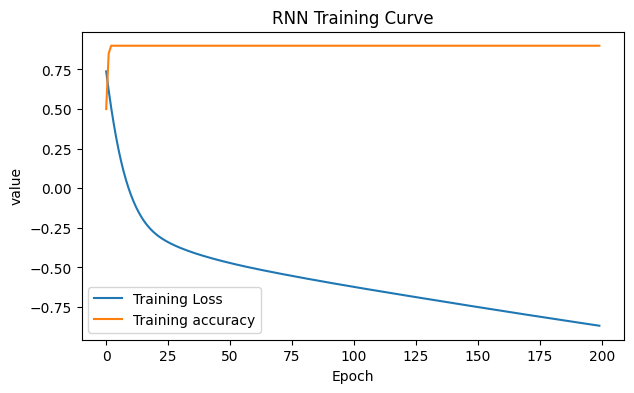

In [91]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(7,4))
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['accuracy'],label='Training accuracy')
plt.title("RNN Training Curve")
plt.xlabel("Epoch")
plt.ylabel("value")
plt.legend()
plt.show()